## Project
Oil and gas facilities rely on pumps, compressors, valves, pipelines, and generators operating continuously. Unexpected equipment failure can cost millions in downtime, lost production, and safety incidents. This notebook applies machine learning to predict failures before they occur, using two complementary approaches: KMeans clustering for unsupervised anomaly detection, and Random Forest classification for supervised failure prediction.

## Importing Libraries

In [1]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score


## Loading the Dataset

The dataset is loaded from a CSV file and inspected. It contains 1,550 rows and 11 columns. Each row represents one hourly sensor reading from an oil and gas equipment.

In [2]:
#Importing my dataframe and checking the first 10 rows
df = pd.read_csv('oil_gas_equipment_failure.csv')
print("Dataframe shape:", df.shape)
df.head(10)

Dataframe shape: (1550, 11)


,timestamp,equipment_id,equipment_type,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label
0,2023-01-01 09:00:00,EQ-018,Generator,5.098,84.92,462.53,1449.4,143.90,43.19,418,0
1,2023-01-01 13:00:00,EQ-015,Pipeline,1.712,76.18,426.89,1516.0,123.74,44.74,65,0
2,2023-01-02 01:00:00,EQ-012,Valve,3.132,79.32,468.07,1503.0,124.38,41.90,320,0
3,2023-01-02 18:00:00,EQ-001,Pipeline,13.300,101.85,339.79,819.9,62.76,67.30,524,1
4,2023-01-03 12:00:00,EQ-012,Valve,2.315,74.56,443.17,1500.1,120.87,52.47,161,0
5,2023-01-03 12:00:00,EQ-014,Compressor,2.259,82.06,439.22,1484.8,117.84,43.19,375,0
6,2023-01-03 16:00:00,EQ-015,Pipeline,3.465,73.62,418.74,1460.2,129.31,47.03,378,0
7,2023-01-03 23:00:00,EQ-012,Valve,3.675,70.79,401.29,1534.2,111.85,45.53,492,0
8,2023-01-04 04:00:00,EQ-013,Generator,3.345,70.32,448.66,1498.7,123.85,43.41,488,0
9,2023-01-04 04:00:00,EQ-012,Valve,4.052,77.12,453.25,1608.1,113.83,44.78,27,0


## Exploratory Data Analysis (EDA)

### 1. Data Types and Missing Values

Checking the data type of each column and identifying any missing values. Four sensor columns contain missing data: vibration_mms (48), temperature_c (42), pressure_psi (46), and oil_flow_rate (44). These will be filled using the column median during preprocessing.

In [3]:
#Checking the data types of each column
print("Data types:", df.dtypes)
#Checking for missing values in the dataset
print("\n        Missing Values:       ")
print(df.isnull().sum())

Data types: timestamp                      str
equipment_id                   str
equipment_type                 str
vibration_mms              float64
temperature_c              float64
pressure_psi               float64
rpm                        float64
oil_flow_rate              float64
current_draw_a             float64
hours_since_maintenance      int64
failure_label                int64
dtype: object

        Missing Values:       
timestamp                   0
equipment_id                0
equipment_type              0
vibration_mms              48
temperature_c              42
pressure_psi               46
rpm                         0
oil_flow_rate              44
current_draw_a              0
hours_since_maintenance     0
failure_label               0
dtype: int64


### 2. Summary Statistics

Generating descriptive statistics for all numeric columns to check for unusual value ranges, extreme minimums or maximums, and overall data scale. This helps identify potential outliers before formal analysis.

In [4]:
#Getting the summary statistics of the dataset from the float and int columns (the numerical columns)
df.describe()

,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label
count,1502.000000,1508.000000,1504.000000,1550.000000,1506.000000,1550.000000,1550.000000,1550.000000
mean,4.675564,80.188375,431.561908,1420.721355,113.146388,49.309555,316.823871,0.129032
std,3.213642,14.515078,55.633970,211.274336,21.232311,12.025625,239.985949,0.335344
min,1.137000,60.230000,179.260000,510.900000,13.190000,34.590000,0.000000,0.000000
25%,3.085250,72.460000,430.542500,1444.625000,109.342500,43.310000,140.000000,0.000000
50%,3.709000,76.020000,447.010000,1487.900000,118.460000,45.400000,287.000000,0.000000
75%,4.404500,80.455000,462.175000,1525.700000,125.585000,48.250000,423.000000,0.000000
max,19.596000,140.430000,506.910000,1647.200000,152.600000,98.690000,1190.000000,1.000000


### 3. Distribution Analysis — Pairplot and Boxplots

Visualising the distribution of each numeric feature using a pairplot (coloured by failure_label) and individual boxplots. The pairplot shows whether sensor readings differ between normal and failed states. Boxplots reveal the spread, median, and outliers for each column.

In [5]:
#Creating a list of the numerical columns in the dataset
num_cols = df.select_dtypes(include=np.number).columns

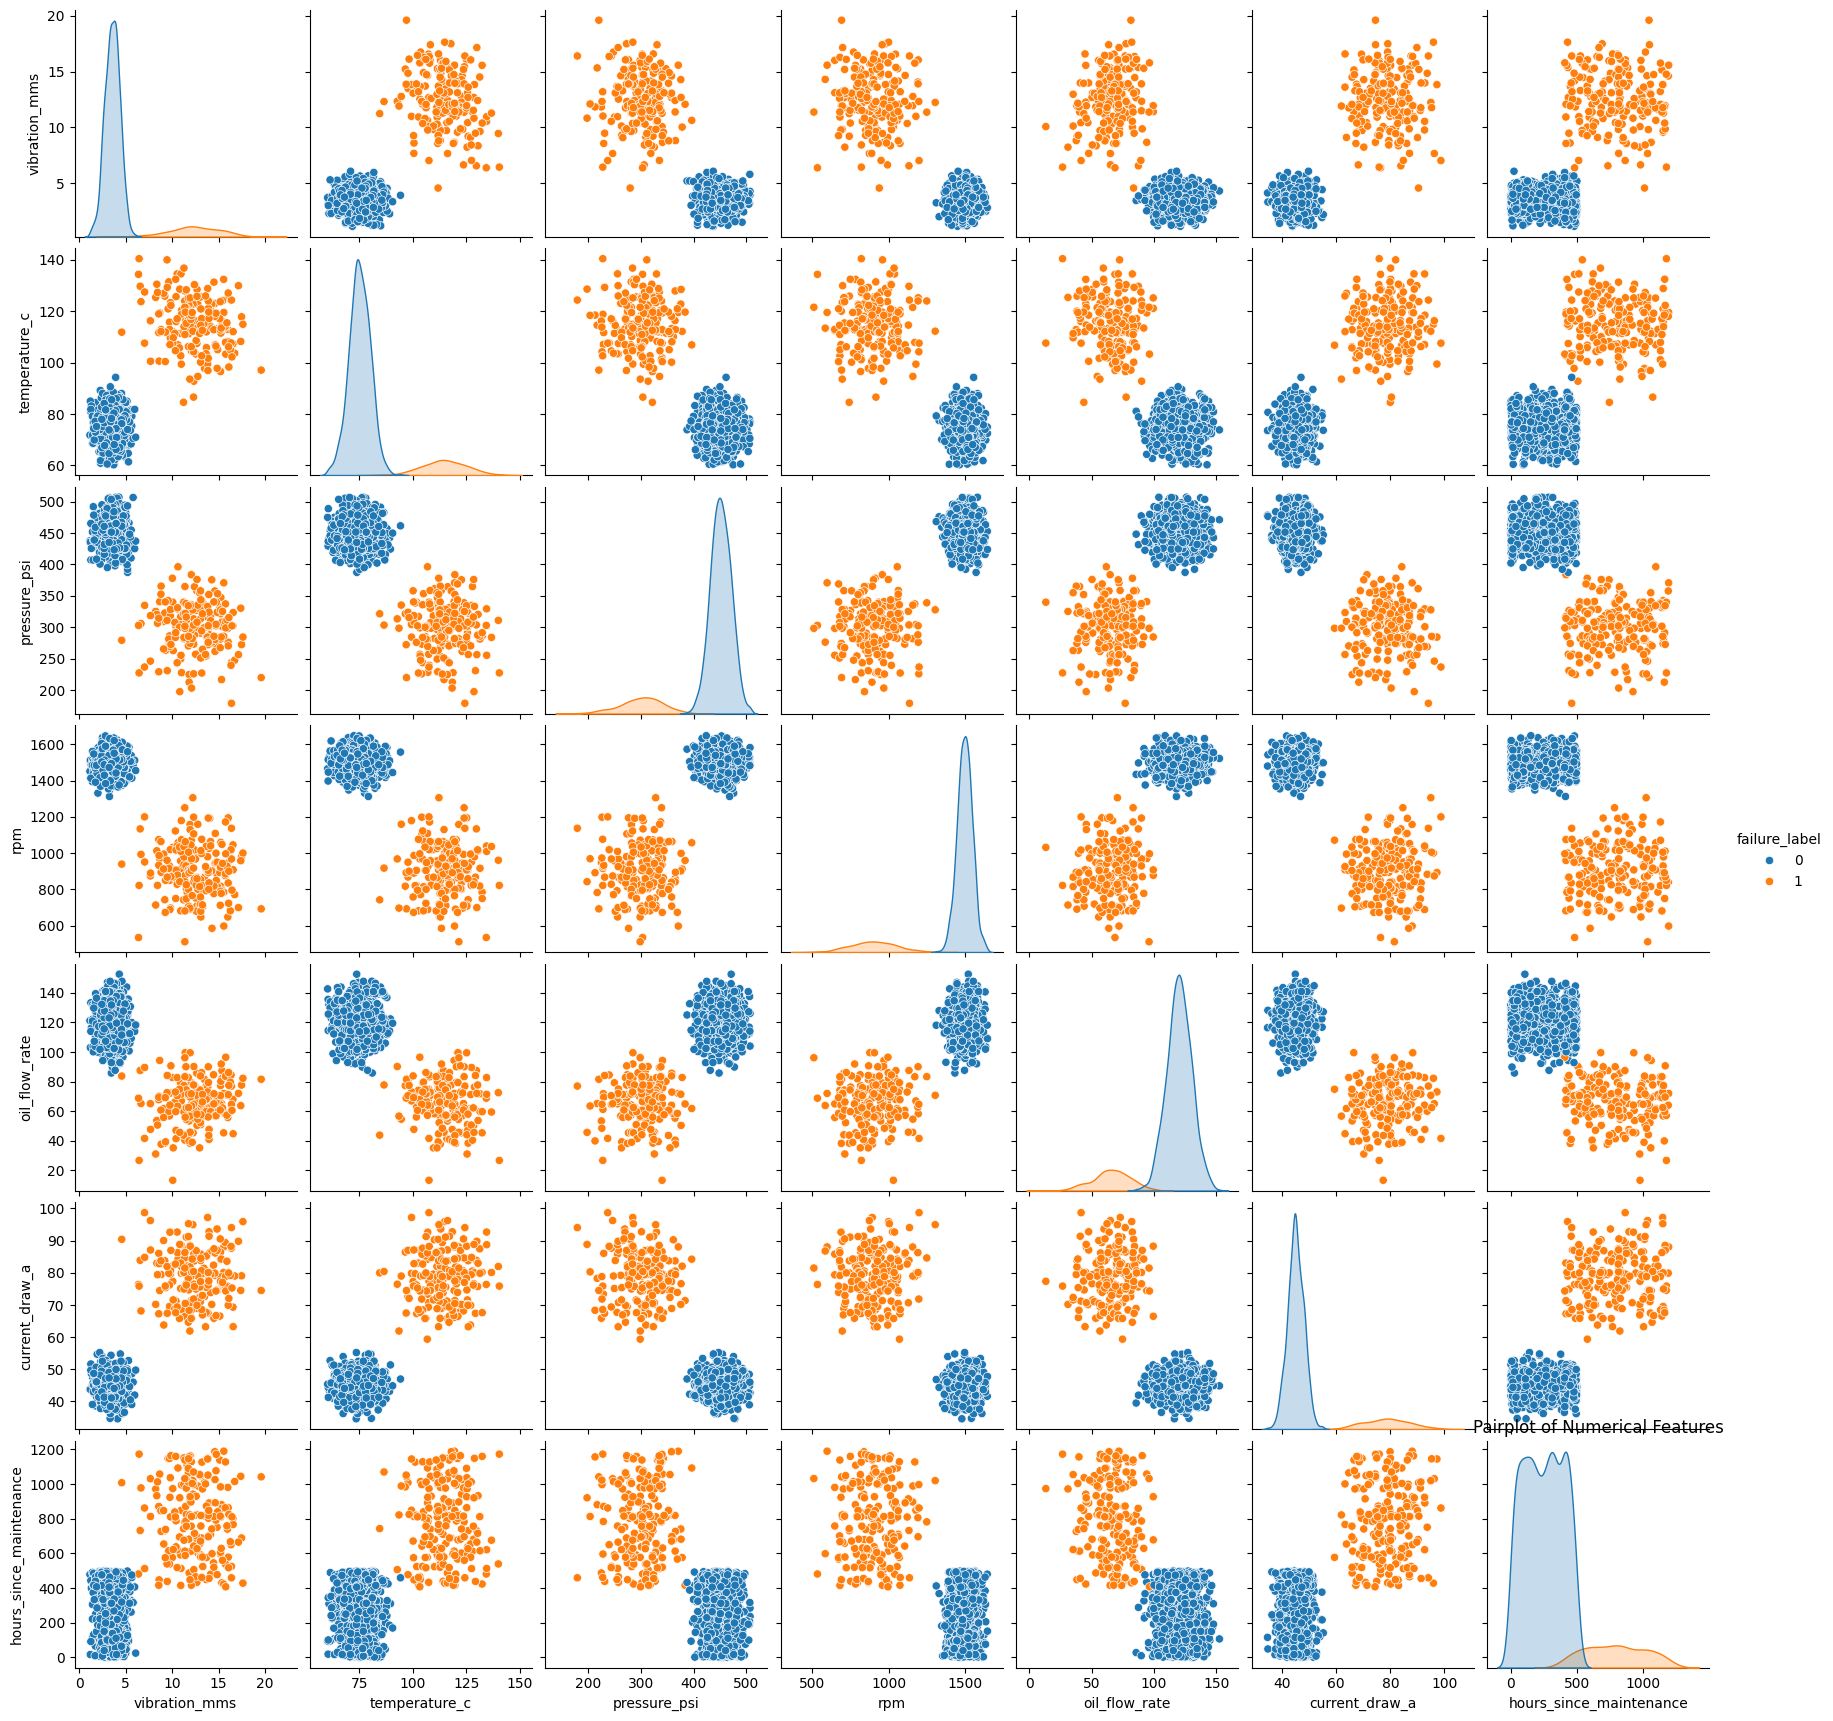

In [6]:
#Using a pairplot to visualize the relationships between the numerical features and the target variable
sns.pairplot(df[num_cols.tolist() ], hue='failure_label')
plt.title("Pairplot of Numerical Features")
plt.savefig("pairplot.png", dpi=150)
plt.show()

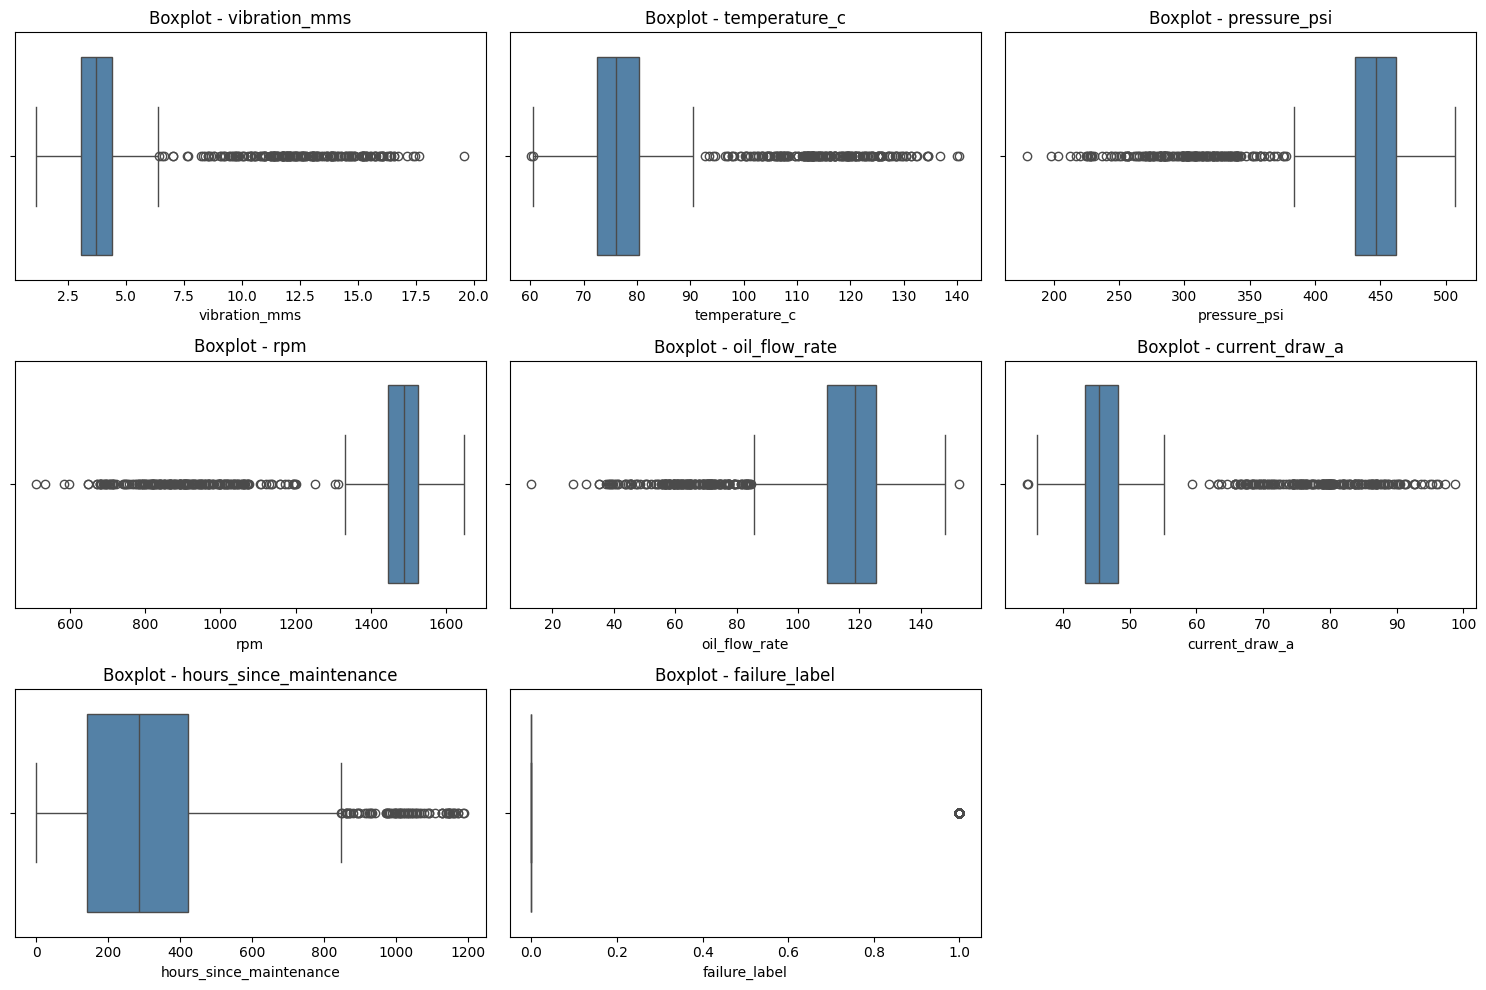

In [7]:
#Boxplots for each numerical feature to identify outliers
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot - {col}')
    axes[i].set_xlabel(col)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()

### 3b. Histogram Analysis

Plotting histograms for each numeric feature to assess the shape of each distribution and identify skewness.

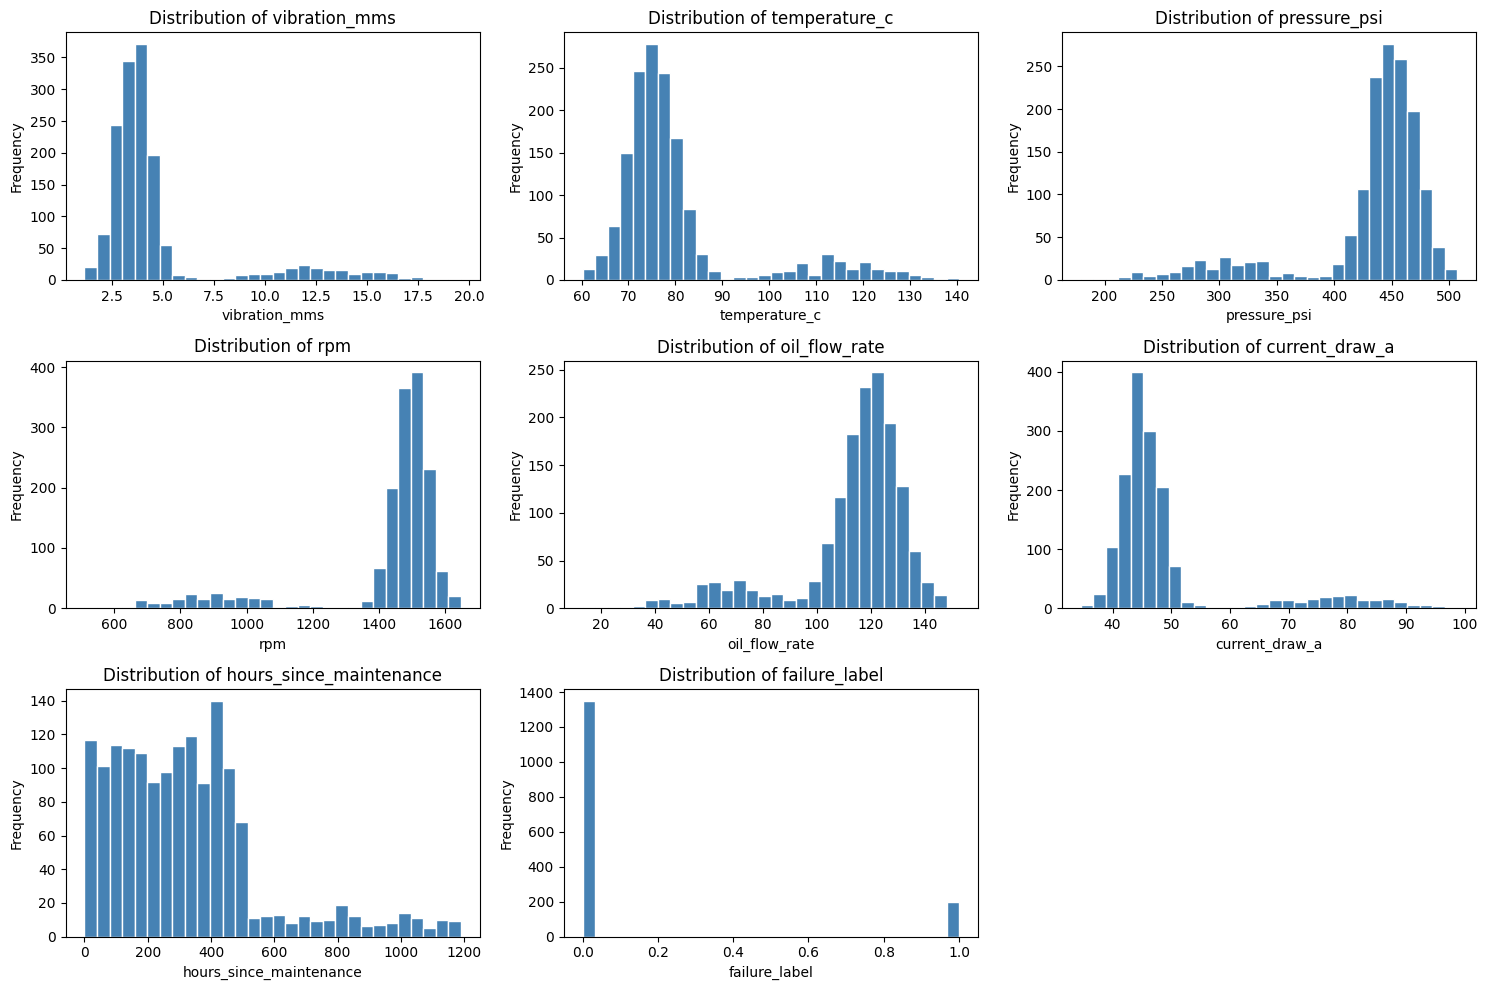

In [8]:
# Plotting histograms for each numeric feature
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('histograms.png', dpi=150)
plt.show()

### 4. Correlation Analysis

Computing and visualising the correlation matrix for all numeric features. This reveals how strongly each sensor reading is linearly related to the target variable (failure_label) and to each other.

The correlation heatmap confirms what the pairplot suggested: almost every sensor column has a strong correlation with failure_label. The weakest correlation is hours_since_maintenance which is 0.76, and this is still an excellent predictive score. All features carry meaningful failure signal and will be retained for modelling.


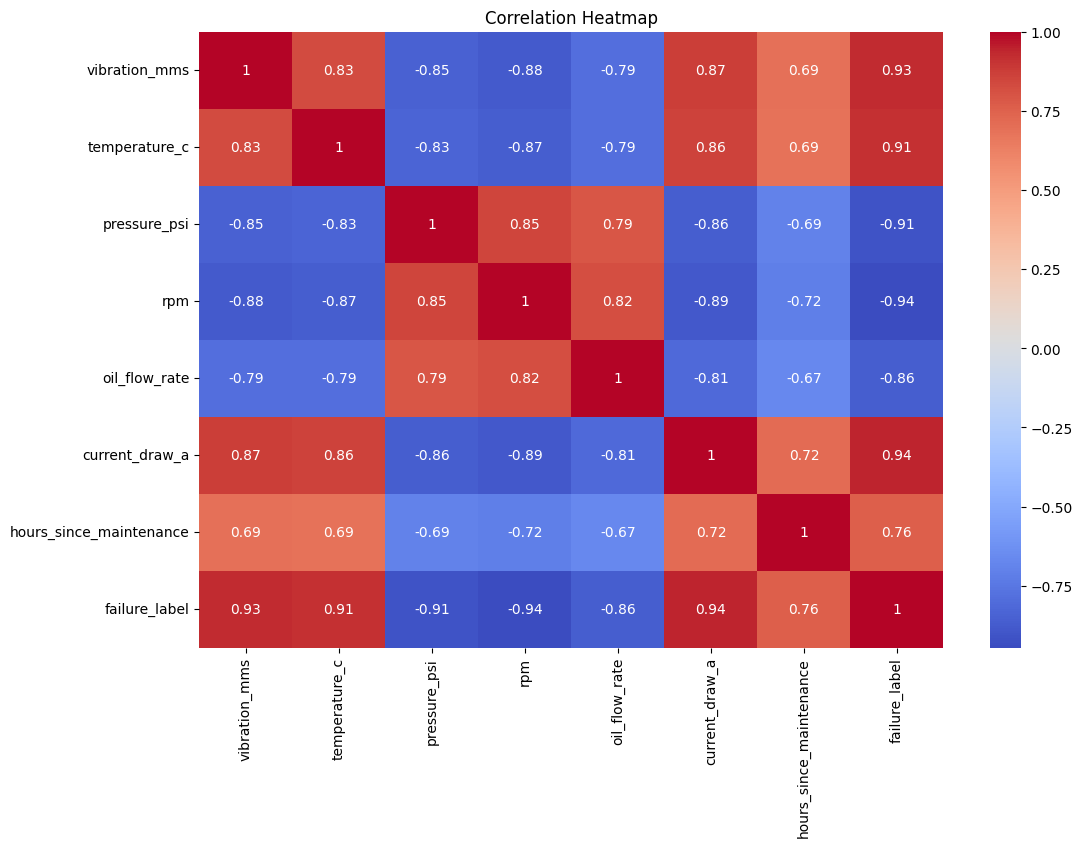

In [9]:
#Correlation heatmap
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

### 5. Failure Class Analysis

Examining the distribution of the target variable to check for class imbalance. A heavily imbalanced dataset (e.g., less than 10% failures) would require special handling such as oversampling or adjusted class weights.

In [10]:
#Count total rows for each label
df['failure_label'].value_counts()
print("Class distribution:\n", (df['failure_label'].value_counts(normalize=True) * 100).round(2))
if df['failure_label'].value_counts().min() / df['failure_label'].value_counts().max() < 0.1:
    print("Warning: Class imbalance detected!")
else:
    print("Class imbalance manageable. No special handling needed.")

Class distribution:
 failure_label
0    87.1
1    12.9
Name: proportion, dtype: float64
Class imbalance manageable. No special handling needed.


### 5b. Sensor Distributions by Failure Label

Plotting sensor distributions split by failure_label to identify which sensors differ most between normal and failure states.

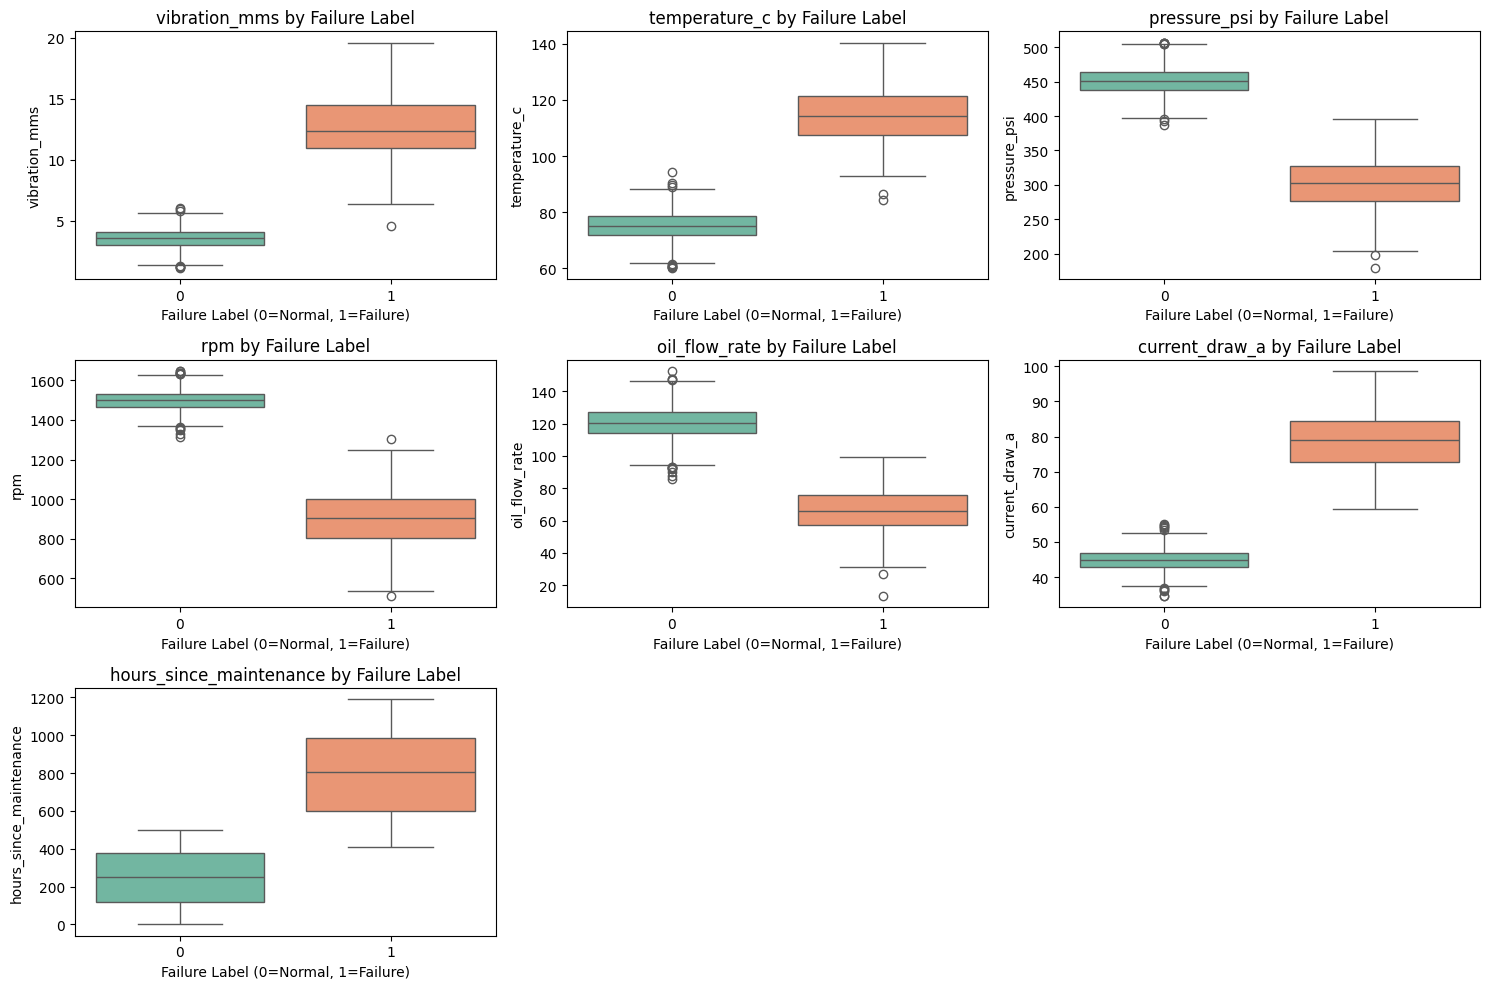

In [11]:
#Grouped boxplots for each sensor split by failure_label
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()
sensor_cols = [c for c in num_cols if c != 'failure_label']
for i, col in enumerate(sensor_cols):
    sns.boxplot(x ='failure_label', y=col, data=df, hue='failure_label', ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'{col} by Failure Label')
    axes[i].set_xlabel('Failure Label (0=Normal, 1=Failure)')
    axes[i].set_ylabel(col)
if len(sensor_cols) < len(axes):
    for j in range(len(sensor_cols), len(axes)):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('sensor_by_failure.png', dpi=150)
plt.show()

### 6. Equipment Level Analysis

Identifying which equipment types and individual machines have the highest failure rates. This provides operationally actionable insight: maintenance teams can prioritise the most failure-prone equipment categories and specific machines.

In [12]:
#Group by Equipment Type to find general vulnerabilities
type_failures = df.groupby('equipment_type')['failure_label'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total_Records', 'sum': 'Total_Failures', 'mean': 'Failure_Rate'}
)
type_failures['Failure_Rate'] = (type_failures['Failure_Rate'] * 100).round(2)
print("--- Failure Analysis by Equipment Type ---")
print(type_failures.sort_values(by='Failure_Rate', ascending=False))

--- Failure Analysis by Equipment Type ---
                Total_Records  Total_Failures  Failure_Rate
equipment_type                                             
Pump                       75              14         18.67
Generator                 479              68         14.20
Compressor                226              31         13.72
Valve                     349              44         12.61
Pipeline                  421              43         10.21


In [13]:
#Group Individual Equipment ID to find "bad" machines
id_failures = df.groupby(['equipment_id', 'equipment_type'])['failure_label'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total_Records', 'sum': 'Total_Failures', 'mean': 'Failure_Rate'}
)
id_failures['Failure_Rate'] = (id_failures['Failure_Rate'] * 100).round(2)
print("\n Top 10 Most Problematic Individual Machines ")
print(id_failures.sort_values(by='Total_Failures', ascending=False).head(10))


 Top 10 Most Problematic Individual Machines 
                             Total_Records  Total_Failures  Failure_Rate
equipment_id equipment_type                                             
EQ-002       Generator                  70              15         21.43
EQ-013       Generator                 102              15         14.71
EQ-016       Compressor                 93              14         15.05
EQ-004       Generator                  81              14         17.28
EQ-019       Pump                       75              14         18.67
EQ-009       Valve                      71              13         18.31
EQ-017       Pipeline                   99              12         12.12
EQ-006       Compressor                 74              11         14.86
EQ-008       Valve                      76              11         14.47
EQ-015       Pipeline                   84              11         13.10


### 6b. Average Sensor Values by Equipment Type

Plotting average sensor readings per equipment type to establish a normal operating baseline for each category.

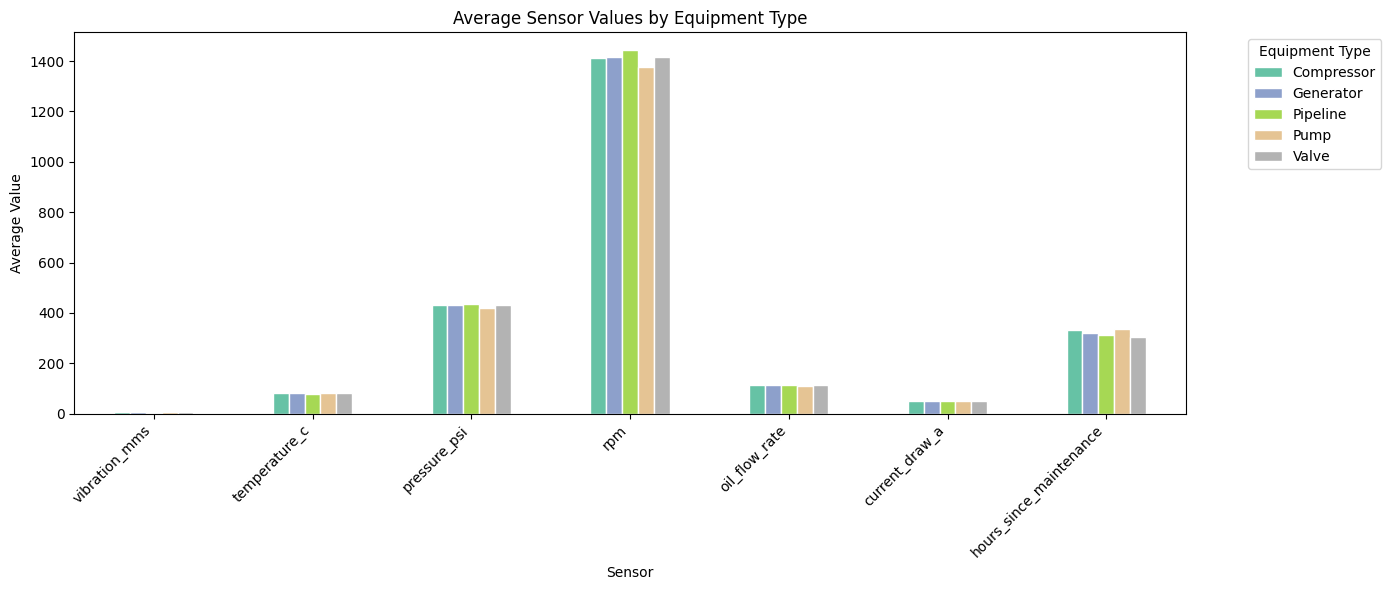

In [14]:
#Average sensor values per equipment type
sensor_cols = [c for c in num_cols if c != 'failure_label']
avg_by_type = df.groupby('equipment_type')[sensor_cols].mean()

avg_by_type.T.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='white')
plt.title('Average Sensor Values by Equipment Type')
plt.xlabel('Sensor')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Equipment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('avg_sensor_by_type.png', dpi=150)
plt.show()

## Data Preprocessing

### 1. Handling Missing Values

Filling missing values in the four sensor columns using each column's own median. The median is preferred over the mean for sensor data because it is robust to outliers, preventing extreme reading from distorting the fill value.

In [15]:
#Fill missing values with mean for numerical columns
missing_cols = num_cols
for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())
print("\nMissing values filled with median for numerical columns.")
print(df.isnull().sum())


Missing values filled with median for numerical columns.
timestamp                  0
equipment_id               0
equipment_type             0
vibration_mms              0
temperature_c              0
pressure_psi               0
rpm                        0
oil_flow_rate              0
current_draw_a             0
hours_since_maintenance    0
failure_label              0
dtype: int64


In [16]:
#Check again for missing values to confirm they are filled
df.head(10)

,timestamp,equipment_id,equipment_type,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label
0,2023-01-01 09:00:00,EQ-018,Generator,5.098,84.92,462.53,1449.4,143.90,43.19,418,0
1,2023-01-01 13:00:00,EQ-015,Pipeline,1.712,76.18,426.89,1516.0,123.74,44.74,65,0
2,2023-01-02 01:00:00,EQ-012,Valve,3.132,79.32,468.07,1503.0,124.38,41.90,320,0
3,2023-01-02 18:00:00,EQ-001,Pipeline,13.300,101.85,339.79,819.9,62.76,67.30,524,1
4,2023-01-03 12:00:00,EQ-012,Valve,2.315,74.56,443.17,1500.1,120.87,52.47,161,0
5,2023-01-03 12:00:00,EQ-014,Compressor,2.259,82.06,439.22,1484.8,117.84,43.19,375,0
6,2023-01-03 16:00:00,EQ-015,Pipeline,3.465,73.62,418.74,1460.2,129.31,47.03,378,0
7,2023-01-03 23:00:00,EQ-012,Valve,3.675,70.79,401.29,1534.2,111.85,45.53,492,0
8,2023-01-04 04:00:00,EQ-013,Generator,3.345,70.32,448.66,1498.7,123.85,43.41,488,0
9,2023-01-04 04:00:00,EQ-012,Valve,4.052,77.12,453.25,1608.1,113.83,44.78,27,0


### 2. Outlier Analysis

Applying the IQR method to every numeric column to count and locate outliers.

**Decision: Keep all sensor outliers.**

Outliers in vibration, temperature, pressure, RPM, oil flow, and current draw are mechanical stress signals, not data errors. Removing them would bias the dataset toward normal operating ranges and make failure detection much harder.

The failure_label column shows 12.9% flagged failures. This aligns closely with the outlier percentages across all sensor columns (11–13%), confirming that these extreme readings represent the failure events themselves.

For hours_since_maintenance, the IQR lower bound is negative (-284.50), which is physically impossible. I choose to keep them because this gives me a rough estimate each equipment can function before another maintenance is needed.

In [17]:
outlier_report = []
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows fall outside the boundaries
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_pct = (outlier_count / df.shape[0]) * 100
    
    outlier_report.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Percentage (%)': round(outlier_pct, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2)
    })

# Convert the results into a clean, scannable DataFrame
report_df = pd.DataFrame(outlier_report)
print(report_df.to_string(index=False))

                 Column  Outlier Count  Percentage (%)  Lower Bound  Upper Bound
          vibration_mms            193           12.45         1.22         6.27
          temperature_c            197           12.71        60.92        91.98
           pressure_psi            194           12.52       385.14       507.70
                    rpm            201           12.97      1323.01      1647.31
          oil_flow_rate            184           11.87        86.60       148.53
         current_draw_a            202           13.03        35.90        55.66
hours_since_maintenance             78            5.03      -284.50       847.50
          failure_label            200           12.90         0.00         0.00


### 3. Feature Engineering

Creating new features from existing columns to give the models richer predictive information.

**Timestamp decomposition:** Extracting hour, day_of_week, and month from the timestamp column. Equipment behaviour may vary with shift patterns, day of the week, and seasonal conditions.

**Rolling statistics:** Computing the rolling mean and standard deviation (window = 5 readings) for vibration and temperature, grouped by equipment_id. Rolling features capture trends and instability over time. A machine deteriorating toward failure typically shows a rising mean and increasing variance in sensor readings.

In [18]:
# Assume df has a 'timestamp' column in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek   #Monday=0, Sunday=6
df['month'] = df['timestamp'].dt.month


In [19]:
#Rolling window size
window = 5
#Sort by equipment_id and timestamp to ensure correct order
df = df.sort_values(['equipment_id', 'timestamp'])
#Rolling mean and rolling standard deviation for vibration and temperature
for col in ['vibration_mms', 'temperature_c']:    
    df[f'{col}_rolling_mean'] = (df.groupby('equipment_id')[col].transform(lambda x: x.rolling(window, min_periods=1).mean()))
    df[f'{col}_rolling_std'] = (df.groupby('equipment_id')[col].transform(lambda x: x.rolling(window, min_periods=1).std()))
# Display the first few rows to verify new features
df.head()

,timestamp,equipment_id,equipment_type,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label,hour,day_of_week,month,vibration_mms_rolling_mean,vibration_mms_rolling_std,temperature_c_rolling_mean,temperature_c_rolling_std
3,2023-01-02 18:00:00,EQ-001,Pipeline,13.300,101.85,339.79,819.9,62.76,67.30,524,1,18,0,1,13.300000,NaN,101.8500,NaN
42,2023-01-11 02:00:00,EQ-001,Pipeline,2.607,69.88,461.60,1552.4,115.23,49.91,134,0,2,2,1,7.953500,7.561093,85.8650,22.606204
68,2023-01-16 10:00:00,EQ-001,Pipeline,5.026,67.82,444.80,1467.2,118.20,49.11,81,0,10,0,1,6.977667,5.607300,79.8500,19.080380
74,2023-01-17 16:00:00,EQ-001,Pipeline,3.709,72.06,485.94,1576.5,109.82,42.26,84,0,16,1,1,6.160500,4.861302,77.9025,16.058589
79,2023-01-19 17:00:00,EQ-001,Pipeline,3.184,76.55,478.48,1570.7,119.71,45.42,356,0,17,3,1,5.565200,4.415439,77.6320,13.920293


### 4. Encoding Categorical Variables

Converting the equipment_type column (Generator, Compressor, Valve, Pipeline, Pump) into binary numeric columns using one-hot encoding (pd.get_dummies). One category is dropped (drop_first=True) to prevent multicollinearity, (where one feature can be perfectly predicted from the others).

In [20]:
# Drop the first category to avoid multicollinearity
df = pd.get_dummies(df, columns=['equipment_type'], drop_first=True, prefix='equip', dtype=int)
df.tail()


,timestamp,equipment_id,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label,...,day_of_week,month,vibration_mms_rolling_mean,vibration_mms_rolling_std,temperature_c_rolling_mean,temperature_c_rolling_std,equip_Generator,equip_Pipeline,equip_Pump,equip_Valve
1430,2023-11-29 23:00:00,EQ-020,2.869,81.87,456.36,1466.8,115.01,42.99,270,0,...,2,11,3.6884,0.775783,78.256,5.763296,0,1,0,0
1469,2023-12-08 15:00:00,EQ-020,7.023,107.56,236.89,1199.6,41.51,98.69,862,1,...,4,12,4.4780,1.583770,84.838,13.801901,0,1,0,0
1480,2023-12-12 14:00:00,EQ-020,2.828,73.01,459.42,1456.0,122.26,45.68,245,0,...,1,12,4.2498,1.749025,82.250,14.723673,0,1,0,0
1506,2023-12-18 18:00:00,EQ-020,5.193,73.97,493.12,1558.6,118.99,49.50,126,0,...,0,12,4.3244,1.786969,82.762,14.290629,0,1,0,0
1527,2023-12-27 05:00:00,EQ-020,3.709,113.80,225.76,972.9,48.40,78.81,1023,1,...,2,12,4.3244,1.786969,90.042,19.277595,0,1,0,0


In [21]:
#Check the final dataframe structure and summary statistics
df.describe()

,timestamp,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label,hour,day_of_week,month,vibration_mms_rolling_mean,vibration_mms_rolling_std,temperature_c_rolling_mean,temperature_c_rolling_std,equip_Generator,equip_Pipeline,equip_Pump,equip_Valve
count,1550,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1550.000000,1530.000000,1550.000000,1530.000000,1550.000000,1550.000000,1550.000000,1550.000000
mean,2023-06-30 20:16:06.193548,4.645632,80.075426,432.020368,1420.721355,113.297226,49.309555,316.823871,0.129032,11.489032,2.997419,6.463226,4.643027,2.413387,80.035965,11.486655,0.309032,0.271613,0.048387,0.225161
min,2023-01-01 09:00:00,1.137000,60.230000,179.260000,510.900000,13.190000,34.590000,0.000000,0.000000,0.000000,0.000000,1.000000,1.712000,0.096451,66.190000,0.042426,0.000000,0.000000,0.000000,0.000000
25%,2023-03-28 02:30:00,3.116250,72.570000,431.100000,1444.625000,109.822500,43.310000,140.000000,0.000000,6.000000,1.000000,3.000000,3.507550,0.684112,74.954500,4.287148,0.000000,0.000000,0.000000,0.000000
50%,2023-07-05 04:30:00,3.709000,76.020000,447.010000,1487.900000,118.460000,45.400000,287.000000,0.000000,11.000000,3.000000,7.000000,4.036100,1.172345,78.044000,7.259604,0.000000,0.000000,0.000000,0.000000
75%,2023-09-29 03:45:00,4.379000,80.335000,461.740000,1525.700000,125.305000,48.250000,423.000000,0.000000,17.750000,5.000000,9.000000,5.511850,4.242174,84.340000,19.026886,1.000000,1.000000,0.000000,0.000000
max,2023-12-31 23:00:00,19.596000,140.430000,506.910000,1647.200000,152.600000,98.690000,1190.000000,1.000000,23.000000,6.000000,12.000000,15.323000,8.215874,114.580000,31.098428,1.000000,1.000000,1.000000,1.000000
std,NaN,3.167890,14.332941,54.864380,211.274336,20.947190,12.025625,239.985949,0.335344,6.922578,2.007409,3.437856,1.513763,2.023639,6.672335,8.267047,0.462244,0.444935,0.214652,0.417823


In [22]:
#Drop timestamp and equipment_id
df1 = df.drop(columns=['timestamp', 'equipment_id'])
df1.head()

,vibration_mms,temperature_c,pressure_psi,rpm,oil_flow_rate,current_draw_a,hours_since_maintenance,failure_label,hour,day_of_week,month,vibration_mms_rolling_mean,vibration_mms_rolling_std,temperature_c_rolling_mean,temperature_c_rolling_std,equip_Generator,equip_Pipeline,equip_Pump,equip_Valve
3,13.300,101.85,339.79,819.9,62.76,67.30,524,1,18,0,1,13.300000,NaN,101.8500,NaN,0,1,0,0
42,2.607,69.88,461.60,1552.4,115.23,49.91,134,0,2,2,1,7.953500,7.561093,85.8650,22.606204,0,1,0,0
68,5.026,67.82,444.80,1467.2,118.20,49.11,81,0,10,0,1,6.977667,5.607300,79.8500,19.080380,0,1,0,0
74,3.709,72.06,485.94,1576.5,109.82,42.26,84,0,16,1,1,6.160500,4.861302,77.9025,16.058589,0,1,0,0
79,3.184,76.55,478.48,1570.7,119.71,45.42,356,0,17,3,1,5.565200,4.415439,77.6320,13.920293,0,1,0,0


In [23]:
print("The final df1.shape is:", df1.shape)

The final df1.shape is: (1550, 19)


### 5. Assigning Features and Target

Separating the dataset into the feature matrix, x(all input columns, 18 features), and the target, y(failure_label).

In [70]:
#Separate features and target variables
y = df1['failure_label'].values
x = df1.drop(columns=['failure_label']).values
print (x.shape, x)
print (y.shape, y)

(1550, 18) [[ 13.3   101.85  339.79  ...   1.      0.      0.   ]
 [  2.607  69.88  461.6   ...   1.      0.      0.   ]
 [  5.026  67.82  444.8   ...   1.      0.      0.   ]
 ...
 [  2.828  73.01  459.42  ...   1.      0.      0.   ]
 [  5.193  73.97  493.12  ...   1.      0.      0.   ]
 [  3.709 113.8   225.76  ...   1.      0.      0.   ]]
(1550,) [1 0 0 ... 0 0 1]


### 6. Train-Test Split

Splitting the data 80/20 into training and test sets. stratify=y ensures the 12.9% failure rate is preserved in both subsets, preventing any accidental imbalance in either set. random_state=42 makes the split reproducible.

In [71]:
#Splitting my data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)
print("Training set shape:", x_train.shape, y_train.shape)
print("Testing set shape:", x_test.shape, y_test.shape)

Training set shape: (1240, 18) (1240,)
Testing set shape: (310, 18) (310,)


### 7. Feature Scaling

Applying StandardScaler to normalise all features to zero mean and unit variance. This is mandatory for KMeans, (which is a distance-based algorithm). Without scaling, high-magnitude features like pressure_psi would dominate the distance calculation over low-magnitude features like vibration_mms, regardless of their actual predictive importance.

After scaling, 40 NaN values were detected, introduced by the rolling standard deviation calculation at the start of each equipment sequence. These are filled using SimpleImputer (mean strategy).

In [26]:
#Standardize the features using StandardScaler for better performance of KMeans.
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print("Feature scaling completed. Sample of scaled features:", x_scaled.shape)

Feature scaling completed. Sample of scaled features: (1550, 18)


In [27]:
#Checking for any NaN values in the scaled training data
print("Missing values in scaled data:", np.isnan(x_scaled).sum())

Missing values in scaled data: 40


In [28]:
#Fill with column mean
imputer = SimpleImputer(strategy='mean')
x_scaled_clean = imputer.fit_transform(x_scaled)
print("Missing values after imputation:", np.isnan(x_scaled_clean).sum())
print("Scaled training data shape after imputation:", x_scaled_clean.shape)

Missing values after imputation: 0
Scaled training data shape after imputation: (1550, 18)


## KMeans Clustering Model (Unsupervised Anomaly Detection)

### 1. Finding the Optimal Number of Clusters — Elbow Method

Testing K values from 2 to 10 and recording the inertia (total within-cluster sum of squared distances) at each K. Inertia always decreases as K increases; the goal is to find the point where further increases in K yield diminishing returns, which is called the **"elbow."**

In [29]:
#testing different k values for k-means, and storing the inertia values for each k
k_range = range(2, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    km.fit(x_scaled_clean)
    inertias.append(km.inertia_)
    print(f'k={k:2d}, inertia: {km.inertia_:.2f}')

k= 2, inertia: 18276.02
k= 3, inertia: 14983.38
k= 4, inertia: 13798.52
k= 5, inertia: 12575.83
k= 6, inertia: 11514.44
k= 7, inertia: 10979.54
k= 8, inertia: 10409.24
k= 9, inertia: 10031.15
k=10, inertia: 9708.22


### 2. Elbow Curve

Plotting inertia against K to visualise the elbow. The point where the curve bends most sharply indicates the optimal K.

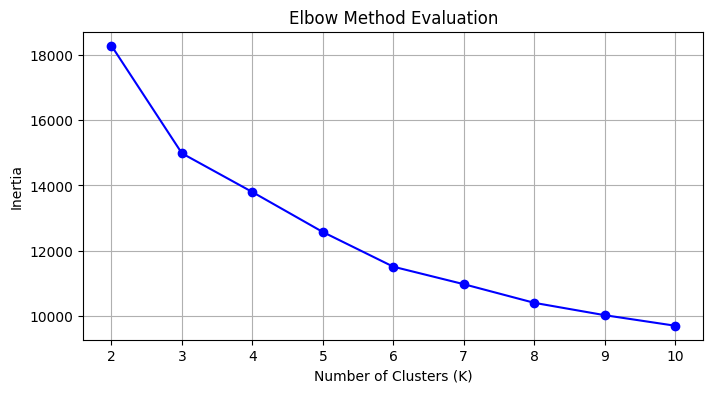

In [30]:
# Plotting the Elbow Curve to justify your final K choice
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker="o", color="b", linestyle="-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method Evaluation")
plt.grid(True)
plt.xticks(k_range)
plt.savefig("elbow_method.png", dpi=150)
plt.show()

### 3. Confirming Optimal K — Silhouette Score

Computing the silhouette score for each K value. The silhouette score measures how well separated the clusters are, ranging from -1 (poor) to +1 (excellent). The K with the highest silhouette score is selected as the optimal number of clusters.

Result: K=2 achieved the highest silhouette score of 0.4736, which more than double the next best value. This confirms the data naturally separates into two groups: normal operation and anomalous/failure readings.

In [31]:
#Finding Optimal Number of Clusters using Silhouette Score
k_range = range(2, 11)
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(x_scaled_clean)
    score = silhouette_score(x_scaled_clean, labels)
    silhouette_scores.append(score)
    print(f'k={k:2d}, silhouette score: {score:.4f}')

#optimal K is the one with the highest silhouette score
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'Optimal K based on silhouette score: {best_k}')

k= 2, silhouette score: 0.4736
k= 3, silhouette score: 0.2396
k= 4, silhouette score: 0.1804
k= 5, silhouette score: 0.2095
k= 6, silhouette score: 0.2300
k= 7, silhouette score: 0.2299
k= 8, silhouette score: 0.2466
k= 9, silhouette score: 0.2211
k=10, silhouette score: 0.1925
Optimal K based on silhouette score: 2


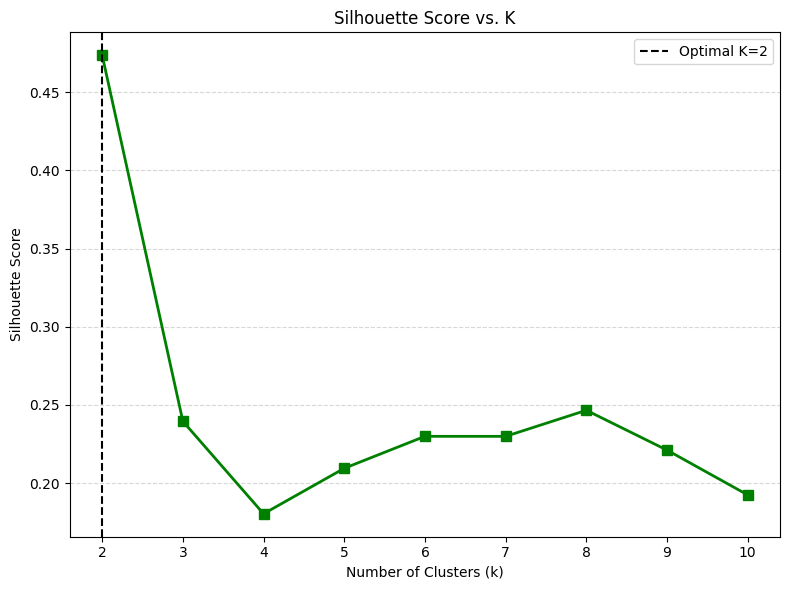

In [32]:
#Plotting Silhouette Scores for each K to visualize the optimal K choice
plt.figure(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, marker='s', color='green', linewidth=2, markersize=7)
plt.axvline(best_k, color='black', linestyle='--', label=f'Optimal K={best_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score') 
plt.title('Silhouette Score vs. K')
plt.xticks(k_range)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('K-means_Silhouette.png', dpi=150)
plt.show()

### 4. Fitting the Final KMeans Model

Fitting the final KMeans model with K=2, confirmed by the silhouette score. The anomaly threshold is set at the 95th percentile of all point-to-centroid distances readings. Any reading beyond this threshold are flagged as potential equipment failures.

In [33]:
#Set best_k from Step 1 (elbow) confirmed by Step 2 (silhouette)
best_k =2 

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, max_iter=300, tol=1e-4, random_state=42)
km_final.fit(x_scaled_clean)
#Assigning cluster labels back to original dataframe
df['Cluster'] = km_final.labels_
print(f'Final K: {best_k}')
print(f'Final Inertia: {km_final.inertia_:.4f}')
print(f'Iteration taken: {km_final.n_iter_}')
print(f'\nCluster Counts:')
print(df['Cluster'].value_counts().sort_index())

Final K: 2
Final Inertia: 18276.0196
Iteration taken: 2

Cluster Counts:
Cluster
0    1350
1     200
Name: count, dtype: int64


### KMeans Anomaly Detection

The KMeans model flagged 78 anomalies with a Precision of 0.2564 and Recall of 0.10. This is expected for an unsupervised model. KMeans has no knowledge of the failure_label during training, so its detection ability is limited compared to a supervised approach. The low recall is a direct consequence of the strict 95th-percentile threshold; lowering it would increase recall at the cost of more false alarms.

The Random Forest model, which is a supervised model, should address this limitation directly.

In [34]:
#Computing the minimum distances of each point to its closest cluster center
closest, min_distances = pairwise_distances_argmin_min(x_scaled_clean, km_final.cluster_centers_)

#Computing the threshold.
threshold = np.percentile(min_distances, 95)

#Converting x_train_scaled to a dataframe.
x_df = pd.DataFrame(x_scaled_clean)

#Adding anomaly flag
x_df["distance_to_center"] = min_distances
x_df["is_anomaly"] = (x_df["distance_to_center"] > threshold).astype(int)

#Print results
print(f"Anomaly Cutoff Distance Threshold: {threshold:.4f}")
print(f"Total anomalies detected: {x_df['is_anomaly'].sum()}")
print(f"Precision: {precision_score(y, x_df['is_anomaly']):.4f}")
print(f"Recall: {recall_score(y, x_df['is_anomaly']):.4f}")


Anomaly Cutoff Distance Threshold: 5.1290
Total anomalies detected: 78
Precision: 0.2564
Recall: 0.1000


### Threshold Trade off

In [35]:
#Threshold experiment: 90th, 95th, and 99th percentile
for pct in [90, 95, 99]:
    thresh = np.percentile(min_distances, pct)
    flagged = (min_distances > thresh).astype(int)
    prec = precision_score(y, flagged)
    rec = recall_score(y, flagged)
    f1 = f1_score(y, flagged)
    tp = ((flagged == 1) & (y == 1)).sum()
    fp = ((flagged == 1) & (y == 0)).sum()
    fn = ((flagged == 0) & (y == 1)).sum()
    print(f"{pct}th percentile | Threshold: {thresh:.4f} | Flagged: {flagged.sum()} | TP: {tp} | FP: {fp} | FN: {fn} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

90th percentile | Threshold: 4.4495 | Flagged: 155 | TP: 38 | FP: 117 | FN: 162 | Precision: 0.2452 | Recall: 0.1900 | F1: 0.2141
95th percentile | Threshold: 5.1290 | Flagged: 78 | TP: 20 | FP: 58 | FN: 180 | Precision: 0.2564 | Recall: 0.1000 | F1: 0.1439
99th percentile | Threshold: 5.8346 | Flagged: 16 | TP: 4 | FP: 12 | FN: 196 | Precision: 0.2500 | Recall: 0.0200 | F1: 0.0370


### 5. PCA 2D Cluster Visualisation

Reducing the 18-dimensional scaled feature matrix to 2 principal components for plotting. Each data point is coloured by its KMeans cluster assignment, with cluster centroids marked as black X symbols. The axis labels show the percentage of total variance explained by each component.

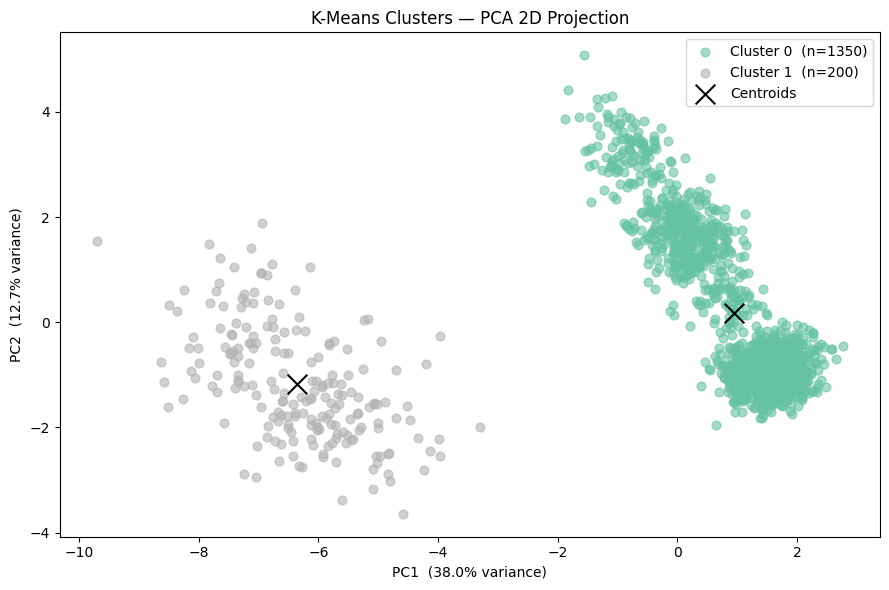

In [ ]:
#Creating a 2D projection of the data using PCA for visualization
pca2 = PCA(n_components=2, random_state=42)
x_2d = pca2.fit_transform(x_scaled_clean)
 
# Centroids in PCA space
centroids_2d = pca2.transform(km_final.cluster_centers_)
 
plt.figure(figsize=(9, 6))
palette = mpl.colormaps['Set2'].resampled(best_k)
for c in range(best_k):
    mask = df['Cluster'] == c
    plt.scatter(x_2d[mask, 0], x_2d[mask, 1],
                color=palette(c), alpha=0.6, s=40,
                label=f'Cluster {c}  (n={mask.sum()})')
 
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            marker='x', s=200, c='black',
            zorder=5, label='Centroids')
plt.xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title("K-Means Clusters — PCA 2D Projection")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_pca2d.png", dpi=150)
plt.show()


## Random Forest Classification Model (Supervised)

### 1. Training, Prediction, and Evaluation

Training the Random Forest classifier on the labelled training set and generating predictions on the test set. The classification report provides the per-class Precision, Recall, and F1-Score. ROC AUC measures the model's overall ability to rank failures above normal readings across all probability thresholds.

In [72]:
#Creating a Random Forest Classifier to predict failure_label using the original features.
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(x_train, y_train)
#Predicting on the test set
y_pred = rf.predict(x_test)

In [73]:
#Evaluating the model on the test set
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, rf.predict_proba(x_test)[:, 1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       270
           1       1.00      1.00      1.00        40

    accuracy                           1.00       310
   macro avg       1.00      1.00      1.00       310
weighted avg       1.00      1.00      1.00       310

Accuracy: 1.0
ROC AUC Score: 1.0


### 2. Confusion Matrix

Visualising the confusion matrix as a heatmap. The matrix shows True Positives (failures correctly caught), True Negatives (normal correctly cleared), False Positives (false alarms), and False Negatives (missed failures). In predictive maintenance, False Negatives are the most costly outcome.

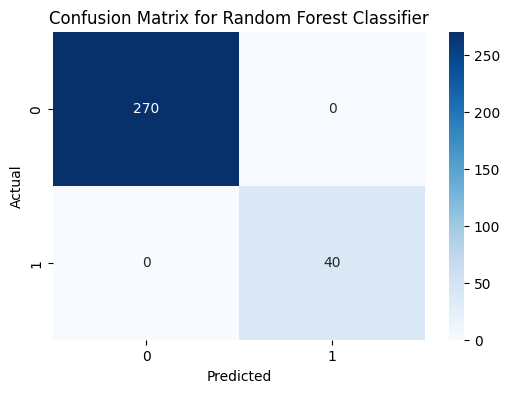

In [74]:
#Create confusion matrix and visualize it with a heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()

### 3. Feature Importance

Ranking all 18 input features by how much they contributed to the Random Forest's decisions across all 100 trees. Higher importance means the model relied on that feature more frequently when splitting decision tree nodes. This reveals which sensors are most critical for predicting equipment failure. Looking at the feature list, hours_since_maintenance scores 6.209921e-02 and is the 7th most critical feature. This confirms the earlier decision to retain hours_since_maintenance was correct because, the model independently identified it as a meaningful predictor.

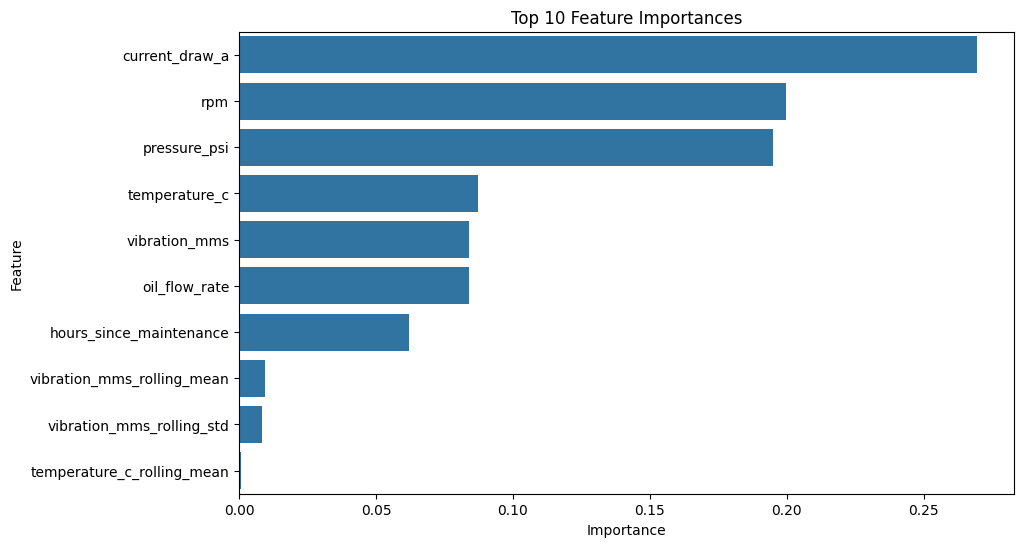

All Feature Importances:
                       Feature    Importance
5               current_draw_a  2.694682e-01
3                          rpm  1.995335e-01
2                 pressure_psi  1.951209e-01
1                temperature_c  8.723697e-02
0                vibration_mms  8.385839e-02
4                oil_flow_rate  8.379458e-02
6      hours_since_maintenance  6.209921e-02
10  vibration_mms_rolling_mean  9.477634e-03
11   vibration_mms_rolling_std  8.474506e-03
12  temperature_c_rolling_mean  6.786933e-04
7                         hour  1.940092e-04
13   temperature_c_rolling_std  3.721778e-05
9                        month  2.622890e-05
15              equip_Pipeline  1.402635e-17
14             equip_Generator  3.350121e-18
8                  day_of_week  3.287950e-18
16                  equip_Pump  0.000000e+00
17                 equip_Valve  0.000000e+00


In [75]:
#Feature importance analysis
feature_names = df1.drop(columns=['failure_label']).columns
importance_df = pd.DataFrame({'Feature': feature_names,'Importance': rf.feature_importances_})
importance_df = (importance_df.sort_values('Importance', ascending=False))
#visualizing the top 10 most important features using a bar plot
top10 = importance_df.head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='Importance', y='Feature')
plt.title("Top 10 Feature Importances")
plt.savefig("feature_importances.png", dpi=150, bbox_inches='tight')
plt.show()
print("All Feature Importances:")
print(importance_df)